# EfficientNet-B3    
## Binary DR Detection (당뇨병성 망막병증 이진 분류 모델)
###dataset_1_ver1

---

**데이터 구조:**
- Train: 1,920 images
- Val: 640 images  
- Test: 640 images
- Label: 0 (No DR), 1 (DR)


## 1. 환경 설정


In [1]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 이동 결과 확인

import os

base_dir = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1'

for split in ['train', 'val', 'test']:
    split_dir = os.path.join(base_dir, split)

    # 상위 폴더 PNG
    pngs = [f for f in os.listdir(split_dir) if f.endswith('.png')]


    print(f"{split}/: {len(pngs)}개 이미지")
    if has_subfolder_0 or has_subfolder_1:
        print(f"  ⚠️ 서브폴더가 아직 있음!")
    else:
        print(f"  ✓ 서브폴더 없음 (정상)")

print("\n✓ 확인 완료!")


train/: 1920개 이미지
  ⚠️ 서브폴더가 아직 있음!
val/: 640개 이미지
  ⚠️ 서브폴더가 아직 있음!
test/: 640개 이미지
  ⚠️ 서브폴더가 아직 있음!

✓ 확인 완료!


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

import timm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# GPU 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA L4


## 2. Configuration

In [5]:
class Config:
    # ⚠️ 경로를 본인의 Google Drive 경로로 수정하세요!
    BASE_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1'

    TRAIN_CSV = f'{BASE_DIR}/manifest_train.csv'
    VAL_CSV = f'{BASE_DIR}/manifest_val.csv'
    TEST_CSV = f'{BASE_DIR}/manifest_test.csv'

    TRAIN_IMG_DIR = f'{BASE_DIR}/train'
    VAL_IMG_DIR = f'{BASE_DIR}/val'
    TEST_IMG_DIR = f'{BASE_DIR}/test'

    OUTPUT_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/EfficientNet-B3/ver1'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 모델 설정
    MODEL_NAME = 'efficientnet_b3'
    IMG_SIZE = 512
    BATCH_SIZE = 16  # GPU 메모리 부족 시 8로 줄이세요
    NUM_WORKERS = 2
    NUM_EPOCHS = 50

    # 학습 설정
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 10
    SEED = 42

config = Config()

# Seed 고정
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
print("✓ Configuration set!")

✓ Configuration set!


## 3. 데이터 확인

In [6]:
# CSV 파일 확인
train_df = pd.read_csv(config.TRAIN_CSV)
val_df = pd.read_csv(config.VAL_CSV)
test_df = pd.read_csv(config.TEST_CSV)

print("Train data:")
print(train_df.head())
print(f"\nShape: {train_df.shape}")
print(f"Label distribution:\n{train_df['label'].value_counts()}")

print("\n" + "="*60)
print(f"Train: {len(train_df)} samples")
print(f"Val:   {len(val_df)} samples")
print(f"Test:  {len(test_df)} samples")

Train data:
   split  img_id  label                                         final_path  \
0  train    1827      0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   
1  train    1829      0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   
2  train     183      0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   
3  train    1828      0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   
4  train    1830      0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...   

                                           orig_path mode  width  height  
0  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
1  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
2  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
3  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  
4  /content/drive/MyDrive/ColabNotebooks/RFMiD_A/...  RGB    512     512  

Shape: (1920, 8)
Label distribution:
label
0    1544
1     376
Name:

## 4. Dataset & DataLoader

In [8]:
class FundusDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['img_id']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (config.IMG_SIZE, config.IMG_SIZE))

        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = FundusDataset(config.TRAIN_CSV, config.TRAIN_IMG_DIR, train_transform)
val_dataset = FundusDataset(config.VAL_CSV, config.VAL_IMG_DIR, val_transform)
test_dataset = FundusDataset(config.TEST_CSV, config.TEST_IMG_DIR, val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS)

print(f"✓ Datasets created!")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val:   {len(val_dataset)} samples")
print(f"  Test:  {len(test_dataset)} samples")

✓ Datasets created!
  Train: 1920 samples
  Val:   640 samples
  Test:  640 samples


## 5. 모델 정의

In [9]:
class EfficientNetB3_BinaryDR(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.model = timm.create_model('efficientnet_b3', pretrained=pretrained, num_classes=1)

    def forward(self, x):
        return self.model(x)

model = EfficientNetB3_BinaryDR(pretrained=True).to(device)
print(f"✓ Model created: EfficientNet-B3")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✓ Model created: EfficientNet-B3
  Total parameters: 10,697,769
  Trainable parameters: 10,697,769


## 6. Loss, Optimizer, Scheduler

In [10]:
# Class Imbalance 처리
train_labels = train_dataset.df['label'].values
n_negative = (train_labels == 0).sum()
n_positive = (train_labels == 1).sum()
pos_weight = n_negative / n_positive

print(f"Class Distribution:")
print(f"  No DR (0): {n_negative} ({n_negative/len(train_labels)*100:.1f}%)")
print(f"  DR (1):    {n_positive} ({n_positive/len(train_labels)*100:.1f}%)")
print(f"  Positive Weight: {pos_weight:.2f}")

# Loss Function (Weighted BCE)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.NUM_EPOCHS)

print(f"\n✓ Loss, Optimizer, Scheduler configured!")

Class Distribution:
  No DR (0): 1544 (80.4%)
  DR (1):    376 (19.6%)
  Positive Weight: 4.11

✓ Loss, Optimizer, Scheduler configured!


## 7. 학습 함수

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.sigmoid(outputs) > 0.5
        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = probs > 0.5

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'accuracy': epoch_acc,
        'auc': epoch_auc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✓ Training functions defined!")

✓ Training functions defined!


## 8. 학습 시작!

In [12]:
# ver1

best_auc = 0.0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

for epoch in range(config.NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{config.NUM_EPOCHS}")
    print(f"{'='*60}")

    # 학습
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # 검증
    val_metrics = validate_epoch(model, val_loader, criterion, device)

    # Scheduler
    scheduler.step()

    # 결과 출력
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    print(f"Val AUC: {val_metrics['auc']:.4f} | Val F1: {val_metrics['f1']:.4f}")
    print(f"Val Precision: {val_metrics['precision']:.4f} | Val Recall: {val_metrics['recall']:.4f}")

    # History 저장
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc'])

    # Best 모델 저장
    if val_metrics['auc'] > best_auc:
        best_auc = val_metrics['auc']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_auc': best_auc,
            'val_metrics': val_metrics
        }, f'{config.OUTPUT_DIR}/best_model.pth')
        print(f"✓ Best model saved! (AUC: {best_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early Stopping
    if patience_counter >= config.PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*60)
print("Training completed!")
print(f"Best Validation AUC: {best_auc:.4f}")
print("="*60)


Epoch 1/50


Validation: 100%|██████████| 40/40 [04:20<00:00,  6.52s/it, loss=1.9212]



Train Loss: 1.1033 | Train Acc: 0.7901
Val Loss: 0.8389 | Val Acc: 0.7531
Val AUC: 0.9482 | Val F1: 0.6146
Val Precision: 0.4532 | Val Recall: 0.9545
✓ Best model saved! (AUC: 0.9482)

Epoch 2/50


Validation: 100%|██████████| 40/40 [00:06<00:00,  6.14it/s, loss=1.1040]



Train Loss: 0.6491 | Train Acc: 0.8646
Val Loss: 0.7931 | Val Acc: 0.8156
Val AUC: 0.9484 | Val F1: 0.6704
Val Precision: 0.5310 | Val Recall: 0.9091
✓ Best model saved! (AUC: 0.9484)

Epoch 3/50


...


Train Loss: 0.0201 | Train Acc: 0.9948
Val Loss: 0.8458 | Val Acc: 0.9313
Val AUC: 0.9726 | Val F1: 0.8308
Val Precision: 0.8438 | Val Recall: 0.8182

Epoch 38/50


Validation: 100%|██████████| 40/40 [00:06<00:00,  6.14it/s, loss=0.3374]



Train Loss: 0.0191 | Train Acc: 0.9964
Val Loss: 0.7457 | Val Acc: 0.9328
Val AUC: 0.9725 | Val F1: 0.8390
Val Precision: 0.8296 | Val Recall: 0.8485

Epoch 39/50


Validation: 100%|██████████| 40/40 [00:06<00:00,  5.96it/s, loss=0.4215]


Train Loss: 0.0053 | Train Acc: 1.0000
Val Loss: 0.6431 | Val Acc: 0.9266
Val AUC: 0.9735 | Val F1: 0.8303
Val Precision: 0.7931 | Val Recall: 0.8712

Early stopping triggered after 39 epochs

Training completed!
Best Validation AUC: 0.9765


## 9. 학습 결과 시각화

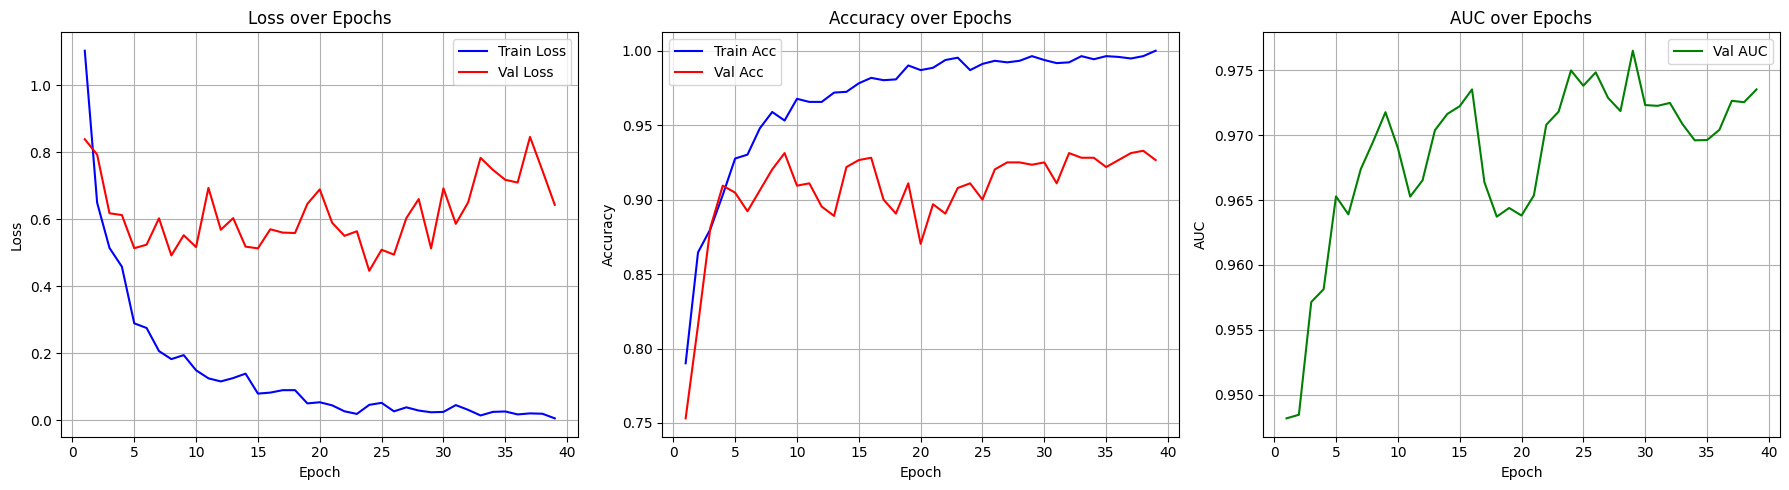

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc')
axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# AUC
axes[2].plot(epochs, history['val_auc'], 'g-', label='Val AUC')
axes[2].set_title('AUC over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/training_history.png', dpi=150)
plt.show()

## 10. Test Set 평가

In [14]:
# Best 모델 로드
checkpoint = torch.load(f'{config.OUTPUT_DIR}/best_model.pth',weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model loaded (Val AUC: {checkpoint['best_auc']:.4f})")

# Test 평가
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)
        preds = probs > 0.5

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# 메트릭 계산
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, zero_division=0)
test_recall = recall_score(all_labels, all_preds, zero_division=0)
test_f1 = f1_score(all_labels, all_preds, zero_division=0)
test_auc = roc_auc_score(all_labels, all_probs)

print(f"\n{'='*60}")
print("TEST RESULTS")
print(f"{'='*60}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"AUC:       {test_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['No DR', 'DR']))

Best model loaded (Val AUC: 0.9765)


Testing: 100%|██████████| 40/40 [03:48<00:00,  5.71s/it]


TEST RESULTS
Accuracy:  0.9328
Precision: 0.8092
Recall:    0.8548
F1 Score:  0.8314
AUC:       0.9744

Confusion Matrix:
[[491  25]
 [ 18 106]]

Classification Report:
              precision    recall  f1-score   support

       No DR       0.96      0.95      0.96       516
          DR       0.81      0.85      0.83       124

    accuracy                           0.93       640
   macro avg       0.89      0.90      0.89       640
weighted avg       0.93      0.93      0.93       640



11. 최종 결과 시각화

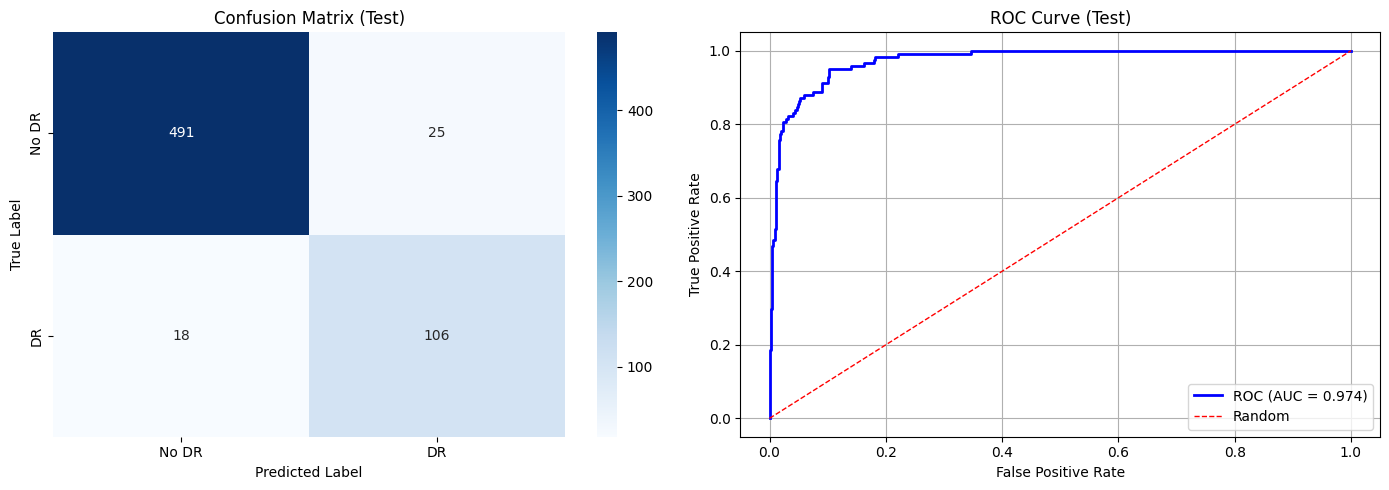


✓ All results saved to: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/EfficientNet-B3/ver1


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'DR'],
            yticklabels=['No DR', 'DR'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Test)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
axes[1].set_title('ROC Curve (Test)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/test_evaluation.png', dpi=150)
plt.show()

print(f"\n✓ All results saved to: {config.OUTPUT_DIR}")

## 12. 결과 저장

In [16]:
import json

results = {
    'best_val_auc': float(best_auc),
    'test_metrics': {
        'accuracy': float(test_acc),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1),
        'auc': float(test_auc)
    },
    'config': {
        'model': config.MODEL_NAME,
        'img_size': config.IMG_SIZE,
        'batch_size': config.BATCH_SIZE,
        'epochs_trained': len(history['train_loss']),
        'learning_rate': config.LEARNING_RATE
    }
}

with open(f'{config.OUTPUT_DIR}/results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✓ Results saved!")
print(f"\nFinal Summary:")
print(f"  Best Val AUC: {best_auc:.4f}")
print(f"  Test AUC:     {test_auc:.4f}")
print(f"  Test Acc:     {test_acc:.4f}")
print(f"\nAll files saved to: {config.OUTPUT_DIR}")

✓ Results saved!

Final Summary:
  Best Val AUC: 0.9765
  Test AUC:     0.9744
  Test Acc:     0.9328

All files saved to: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/EfficientNet-B3/ver1
